# T-CRL: Temporal Causal Representation Learning for Behavioral Outcome Prediction
EC523 Deep Learning — Boston University

In [1]:
# install deps
!pip install scikit-learn seaborn --quiet

# fresh clone every time to avoid stale cached code
!rm -rf /content/EC523
!git clone https://github.com/ezheng05/EC523.git /content/EC523 --quiet

# clear any compiled bytecode
!find /content/EC523 -type d -name __pycache__ -exec rm -rf {} + 2>/dev/null; true

import sys, os, random
import numpy as np
import torch
sys.path.insert(0, '/content/EC523')

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# mount drive for dataset access
from google.colab import drive
drive.mount('/content/drive')

# adjust this path if your dataset is in a different Drive folder
DATASET_ROOT = '/content/drive/MyDrive/globem-dataset-multi-year-datasets-for-longitudinal-human-behavior-modeling-generalization-1.1'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import sys, os
sys.path.insert(0, '/content/EC523')

import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from config.config import ModelConfig
from src.data.dataset import make_splits
from src.models.encoder import TCRL_Encoder, Baseline_Standard_Encoder
from src.models.vae import TCRL_BetaVAE
from src.training.trainer import train_epoch, evaluate
from src.utils.metrics import compute_regression_metrics, compute_auc_metrics, print_metrics, TARGET_NAMES

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

!nvidia-smi

device: cuda
Mon Apr 27 20:39:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   40C    P0             57W /  400W |       6MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+----------------------------------

In [4]:
cfg = ModelConfig()

cohort_dirs = [os.path.join(DATASET_ROOT, c) for c in cfg.cohorts]
for d in cohort_dirs:
    if not os.path.isdir(d):
        print(f'WARNING: missing cohort dir: {d}')

train_ds, val_ds, test_ds = make_splits(
    cohort_dirs, seq_len=cfg.seq_len,
    val_ratio=cfg.val_ratio, test_ratio=cfg.test_ratio
)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=cfg.batch_size, num_workers=2, pin_memory=True)

loading cohorts...
  INS-W_1
  INS-W_2
  INS-W_3
  INS-W_4
shared features: 3390
split: train=461 val=99 test=97


In [5]:
from src.data.dataset import BASELINE_COLS
from src.utils.metrics import compute_regression_metrics, TARGET_NAMES

feat_dim = train_ds.feat_dim
ehr_dim  = len(BASELINE_COLS)

enc  = TCRL_Encoder(feat_dim=feat_dim, seq_len=cfg.seq_len, ehr_dim=ehr_dim, hidden_dim=cfg.hidden_dim, dropout=cfg.dropout)
tcrl = TCRL_BetaVAE(enc, latent_dim=cfg.latent_dim, num_targets=cfg.num_targets).to(device)
opt   = optim.Adam(tcrl.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)

train_losses, val_losses = [], []
best_val, patience_count = float('inf'), 0
best_state_tcrl = None

print('--- training t-crl ---')
for epoch in range(cfg.epochs):
    stats = train_epoch(tcrl, train_loader, opt, device, cfg.beta, cfg.lambda_sparsity, cfg.grad_clip)
    train_losses.append(stats['task'])
    if (epoch + 1) % cfg.eval_every == 0:
        vp, vt = evaluate(tcrl, val_loader, device)
        val_mse = float(((vp - vt) ** 2).mean())
        val_losses.append(val_mse)
        reg = compute_regression_metrics(vp, vt)
        r2_str = ' '.join(f"{n[:4]}={reg[n]['r2']:.2f}" for n in TARGET_NAMES)
        print(f'epoch {epoch+1:03d}/{cfg.epochs} | task: {stats["task"]:.4f} | val mse: {val_mse:.4f} | {r2_str}', flush=True)
        sched.step(val_mse)
        if val_mse < best_val:
            best_val = val_mse
            best_state_tcrl = {k: v.detach().clone() for k, v in tcrl.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= cfg.early_stop_patience:
                print(f'early stop at epoch {epoch+1}')
                break

# restore best weights for downstream eval
if best_state_tcrl is not None:
    tcrl.load_state_dict(best_state_tcrl)
    print(f'restored best t-crl (val mse: {best_val:.4f})')

--- training t-crl ---
epoch 005/150 | task: 0.9776 | val mse: 43.1029 | depr=0.05 anxi=0.10 stre=0.12 lone=0.06 resi=0.05
epoch 010/150 | task: 0.7394 | val mse: 28.0754 | depr=0.36 anxi=0.45 stre=0.43 lone=0.20 resi=0.24
epoch 015/150 | task: 0.6546 | val mse: 28.4849 | depr=0.38 anxi=0.43 stre=0.36 lone=0.31 resi=0.21
epoch 020/150 | task: 0.6589 | val mse: 28.4501 | depr=0.43 anxi=0.42 stre=0.39 lone=0.32 resi=0.25
epoch 025/150 | task: 0.6021 | val mse: 29.3693 | depr=0.40 anxi=0.40 stre=0.35 lone=0.30 resi=0.28
epoch 030/150 | task: 0.5727 | val mse: 30.8329 | depr=0.30 anxi=0.39 stre=0.32 lone=0.24 resi=0.28
epoch 035/150 | task: 0.5700 | val mse: 32.5244 | depr=0.26 anxi=0.33 stre=0.32 lone=0.26 resi=0.25
epoch 040/150 | task: 0.5592 | val mse: 28.6767 | depr=0.31 anxi=0.44 stre=0.37 lone=0.26 resi=0.29
epoch 045/150 | task: 0.5202 | val mse: 28.2038 | depr=0.35 anxi=0.45 stre=0.35 lone=0.31 resi=0.26
epoch 050/150 | task: 0.5272 | val mse: 29.0510 | depr=0.31 anxi=0.43 stre=0.

In [6]:
b_enc  = Baseline_Standard_Encoder(feat_dim=feat_dim, seq_len=cfg.seq_len, ehr_dim=ehr_dim, hidden_dim=cfg.hidden_dim, dropout=cfg.dropout)
bmodel = TCRL_BetaVAE(b_enc, latent_dim=cfg.latent_dim, num_targets=cfg.num_targets).to(device)
b_opt   = optim.Adam(bmodel.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
b_sched = optim.lr_scheduler.ReduceLROnPlateau(b_opt, mode='min', factor=0.5, patience=3)

b_train_losses, b_val_losses = [], []
b_best_val, b_patience = float('inf'), 0
best_state_b = None

print('--- training baseline (no missingness gate) ---')
for epoch in range(cfg.epochs):
    stats = train_epoch(bmodel, train_loader, b_opt, device, cfg.beta, cfg.lambda_sparsity, cfg.grad_clip)
    b_train_losses.append(stats['task'])
    if (epoch + 1) % cfg.eval_every == 0:
        vp, vt = evaluate(bmodel, val_loader, device)
        val_mse = float(((vp - vt) ** 2).mean())
        b_val_losses.append(val_mse)
        reg = compute_regression_metrics(vp, vt)
        r2_str = ' '.join(f"{n[:4]}={reg[n]['r2']:.2f}" for n in TARGET_NAMES)
        print(f'epoch {epoch+1:03d}/{cfg.epochs} | task: {stats["task"]:.4f} | val mse: {val_mse:.4f} | {r2_str}', flush=True)
        b_sched.step(val_mse)
        if val_mse < b_best_val:
            b_best_val = val_mse
            best_state_b = {k: v.detach().clone() for k, v in bmodel.state_dict().items()}
            b_patience = 0
        else:
            b_patience += 1
            if b_patience >= cfg.early_stop_patience:
                print(f'early stop at epoch {epoch+1}')
                break

if best_state_b is not None:
    bmodel.load_state_dict(best_state_b)
    print(f'restored best baseline (val mse: {b_best_val:.4f})')

--- training baseline (no missingness gate) ---
epoch 005/150 | task: 0.9431 | val mse: 46.1454 | depr=0.03 anxi=-0.01 stre=0.09 lone=0.11 resi=0.07
epoch 010/150 | task: 0.7112 | val mse: 30.2616 | depr=0.37 anxi=0.38 stre=0.33 lone=0.28 resi=0.28
epoch 015/150 | task: 0.6304 | val mse: 28.5543 | depr=0.30 anxi=0.45 stre=0.38 lone=0.23 resi=0.27
epoch 020/150 | task: 0.6377 | val mse: 27.8819 | depr=0.35 anxi=0.45 stre=0.42 lone=0.28 resi=0.31
epoch 025/150 | task: 0.6067 | val mse: 27.3098 | depr=0.33 anxi=0.49 stre=0.36 lone=0.26 resi=0.26
epoch 030/150 | task: 0.5711 | val mse: 29.3111 | depr=0.34 anxi=0.42 stre=0.33 lone=0.31 resi=0.30
epoch 035/150 | task: 0.5664 | val mse: 27.3297 | depr=0.39 anxi=0.45 stre=0.40 lone=0.37 resi=0.30
epoch 040/150 | task: 0.5638 | val mse: 31.5086 | depr=0.20 anxi=0.40 stre=0.28 lone=0.22 resi=0.21
epoch 045/150 | task: 0.5780 | val mse: 26.8064 | depr=0.37 anxi=0.49 stre=0.39 lone=0.27 resi=0.31
epoch 050/150 | task: 0.5609 | val mse: 29.1786 | d

In [7]:
print('=== test results ===')
for name, model in [('t-crl', tcrl), ('baseline', bmodel)]:
    y_pred, y_true = evaluate(model, test_loader, device)
    reg = compute_regression_metrics(y_pred, y_true)
    auc = compute_auc_metrics(y_pred, y_true)
    print(f'\n{name}:')
    print_metrics(reg, auc)

=== test results ===

t-crl:
target            rmse     mae  pearson_r      r2  auc_roc  auc_pr
------------------------------------------------------------------
depression       4.016   3.339      0.617   0.329    0.823   0.766
anxiety          8.063   6.411      0.706   0.462    0.844   0.890
stress           5.048   4.062      0.657   0.393    0.867   0.935
loneliness       4.791   3.864      0.536   0.271    0.793   0.566
resilience       0.555   0.446      0.587   0.337    0.782   0.697

baseline:
target            rmse     mae  pearson_r      r2  auc_roc  auc_pr
------------------------------------------------------------------
depression       4.046   3.226      0.581   0.319    0.833   0.744
anxiety          8.237   6.527      0.673   0.438    0.840   0.869
stress           4.986   3.938      0.640   0.407    0.847   0.922
loneliness       5.052   4.144      0.447   0.189    0.749   0.487
resilience       0.560   0.451      0.572   0.327    0.778   0.657


In [8]:
print('=== per-cohort test results (t-crl) ===')

# get full test predictions/targets in original scale, then partition by cohort
yp_all, yt_all = evaluate(tcrl, test_loader, device)
yp_all, yt_all = yp_all.numpy(), yt_all.numpy()

co_of   = test_ds.cohort_of
co_name = test_ds.cohort_names
test_uids = test_ds.users

import torch as _t
groups = {}
for i, uid in enumerate(test_uids):
    groups.setdefault(co_of[uid], []).append(i)

for c_idx, idxs in sorted(groups.items()):
    yp_c = _t.from_numpy(yp_all[idxs])
    yt_c = _t.from_numpy(yt_all[idxs])
    reg = compute_regression_metrics(yp_c, yt_c)
    parts = ' '.join(f"{n[:4]}={reg[n]['r2']:.3f}" for n in TARGET_NAMES)
    print(f"  {co_name[c_idx]:<10} (n={len(idxs):>3}) | {parts}")

=== per-cohort test results (t-crl) ===
  INS-W_1    (n= 18) | depr=0.233 anxi=0.528 stre=0.359 lone=0.082 resi=0.034
  INS-W_2    (n= 29) | depr=0.289 anxi=0.450 stre=0.498 lone=0.218 resi=0.158
  INS-W_3    (n= 21) | depr=0.296 anxi=0.492 stre=0.214 lone=0.262 resi=0.545
  INS-W_4    (n= 29) | depr=0.272 anxi=0.515 stre=0.480 lone=0.281 resi=0.388


ValueError: x and y must have same first dimension, but have shapes (14,) and (21,)

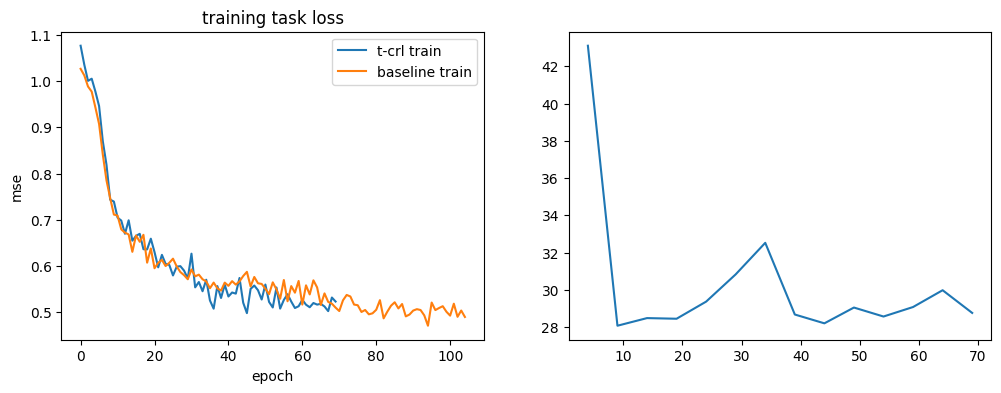

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='t-crl train')
axes[0].plot(b_train_losses, label='baseline train')
axes[0].set_title('training task loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('mse')
axes[0].legend()

x_ticks = list(range(cfg.eval_every - 1, cfg.epochs, cfg.eval_every))[:len(val_losses)]
axes[1].plot(x_ticks, val_losses, label='t-crl val')
axes[1].plot(x_ticks[:len(b_val_losses)], b_val_losses, label='baseline val')
axes[1].set_title('validation mse')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('mse')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, model) in zip(axes, [('t-crl', tcrl), ('baseline', bmodel)]):
    adj = model.adj.detach().cpu().numpy()
    sparsity = float((np.abs(adj) < 0.01).mean())
    sns.heatmap(adj, annot=True, cmap='coolwarm', center=0, fmt='.3f', ax=ax)
    ax.set_title(f'{name} causal adjacency  (sparsity: {sparsity:.0%})')
    ax.set_xlabel('effect (latent dim)')
    ax.set_ylabel('cause (latent dim)')

plt.tight_layout()
plt.show()

In [ ]:
y_pred, y_true = evaluate(tcrl, test_loader, device)
y_pred, y_true = y_pred.numpy(), y_true.numpy()

n = len(TARGET_NAMES)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()
for i, name in enumerate(TARGET_NAMES):
    ax = axes[i]
    ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.5, s=20)
    lo = min(y_true[:, i].min(), y_pred[:, i].min())
    hi = max(y_true[:, i].max(), y_pred[:, i].max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_xlabel('actual')
    ax.set_ylabel('predicted')
    ax.set_title(name)

# hide unused subplots
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('t-crl: predicted vs actual (test set)', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
import json
import numpy as np

def _serialize(obj):
    if isinstance(obj, (np.floating, np.integer)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

all_results = {}
for name, model in [('tcrl', tcrl), ('baseline', bmodel)]:
    yp, yt = evaluate(model, test_loader, device)
    reg = compute_regression_metrics(yp, yt)
    auc = compute_auc_metrics(yp, yt)
    all_results[name] = {
        t: {k: _serialize(v) for k, v in {**reg[t], **auc.get(t, {})}.items()}
        for t in TARGET_NAMES
    }

all_results['tcrl_val_mse'] = float(best_val)
all_results['baseline_val_mse'] = float(b_best_val)
all_results['status'] = 'done'

with open('/content/drive/MyDrive/tcrl_status.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print(json.dumps(all_results, indent=2))